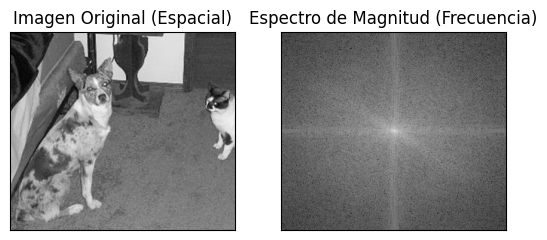

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. Cargar imagen y pasarla a gris (señal 2D simple)
img = cv2.imread('../../data/petimages/Cat/.jpg', cv2.IMREAD_GRAYSCALE)
img = img / 255.0

# 2. Aplicar FFT (Transformada Rápida de Fourier)
# fft2 hace la magia en 2 dimensiones
f_transform = np.fft.fft2(img)

# 3. Centrar el resultado
# La FFT pone la frecuencia 0 en la esquina. Shift la mueve al centro.
f_shift = np.fft.fftshift(f_transform)

# 4. Calcular la Magnitud
# Como los valores son complejos, sacamos el valor absoluto.
# Aplicamos logaritmo porque los valores centrales son miles de veces 
# más grandes que los de las orillas.
magnitude_spectrum = 20 * np.log(np.abs(f_shift))

# Visualización
plt.subplot(121), plt.imshow(img, cmap='gray')
plt.title('Imagen Original (Espacial)'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Espectro de Magnitud (Frecuencia)'), plt.xticks([]), plt.yticks([])
plt.show()

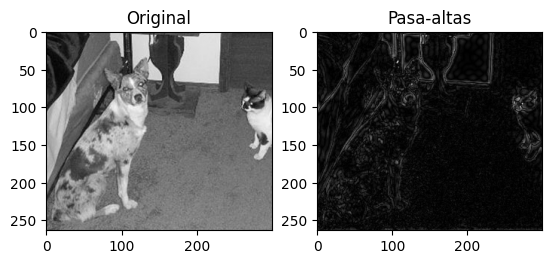

In [2]:
# El error ocurre porque:
# 1. cv2.IMREAD_COLOR_RGB no existe, la forma correcta es cv2.IMREAD_COLOR o cv2.IMREAD_GRAYSCALE.
# 2. Si la imagen la cargas a color, img tendrá forma (alto, ancho, 3), por lo que intentar hacer rows, cols = img.shape da error ("too many values to unpack").
# 3. La FFT espera una matriz 2D (escala de grises), no una imagen a color.

import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. Leer imagen en escala de grises (¡ahora correctamente!)
img = cv2.imread("../../data/petimages/Dog/7.jpg", cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError("No se encontró la imagen, revisa la ruta.")

# 2. FFT sobre la imagen 2D
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)

# 3. Crear máscara pasa-bajas
rows, cols = img.shape
crow, ccol = rows // 2, cols // 2

mask = np.ones((rows, cols), np.uint8)
radio = 20  # <-- controla qué tanto se borra (la zona central, que corresponde a bajas frecuencias)
y, x = np.ogrid[:rows, :cols]
mask_area = (x - ccol)**2 + (y - crow)**2 <= radio**2
mask[mask_area] = 0

# 4. Aplicar máscara (el resultado es una imagen donde has eliminado las bajas frecuencias)
fshift_filtrado = fshift * mask

# 5. Inversa
f_ishift = np.fft.ifftshift(fshift_filtrado)
img_back = np.fft.ifft2(f_ishift)
img_back = np.abs(img_back)

# 6. Mostrar
plt.subplot(121)
plt.imshow(img, cmap='gray')
plt.title("Original")

plt.subplot(122)
plt.imshow(img_back, cmap='gray')
plt.title("Pasa-altas")

plt.show()

# Resumen del problema:
# El error sale porque intentabas desempaquetar .shape de una imagen a color (tres dimensiones) en sólo dos variables.
# Además, para este tipo de filtrado en Fourier, la imagen debe ser en escala de grises (2D), no color (3D).

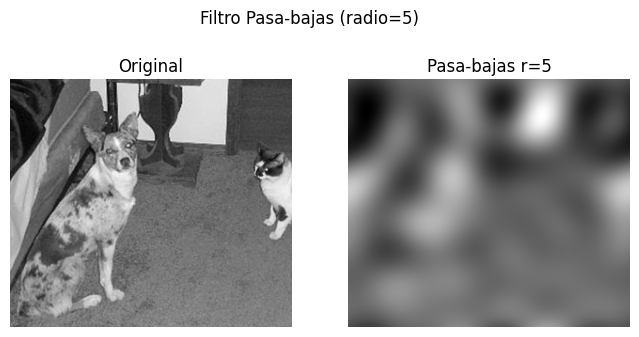

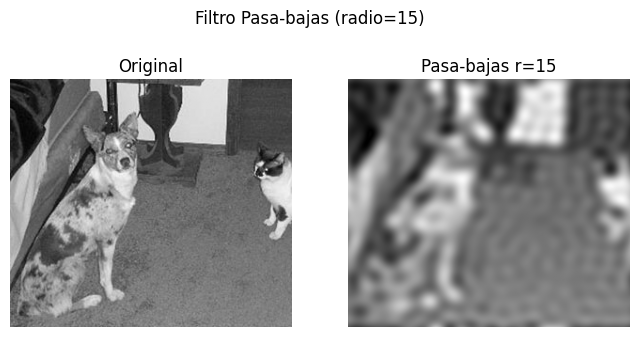

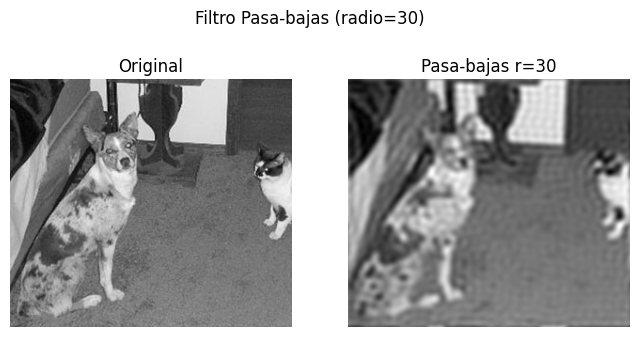

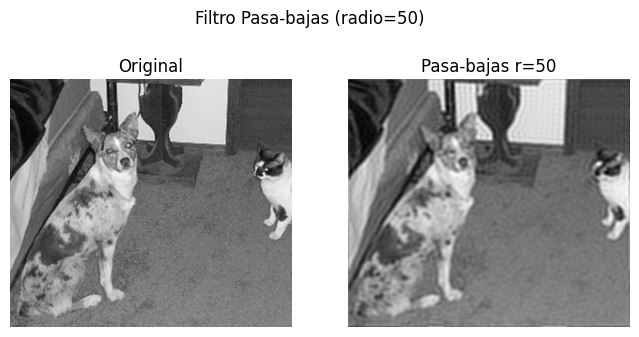

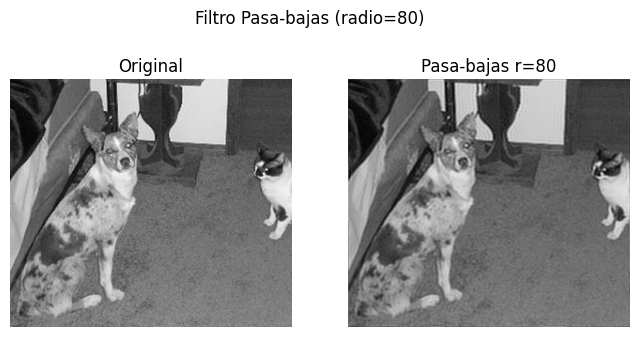

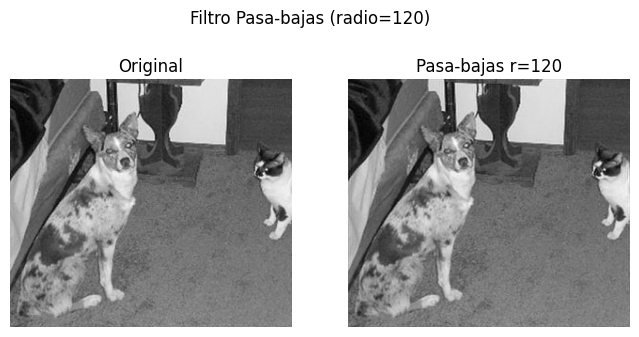

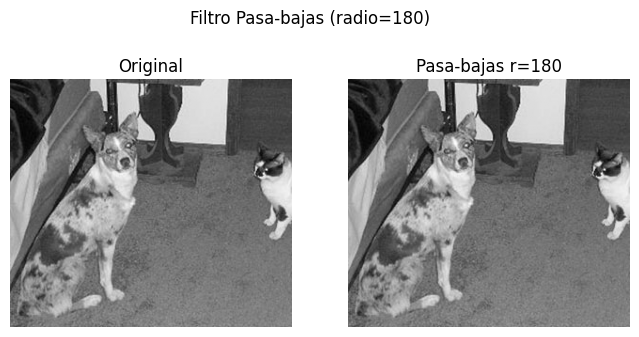

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

filename = "7.jpg"
filename_dir = '../../data/petimages/Dog/'
save_dir = './source/data/petimages/fourier'

# Aseguramos que la carpeta existe
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 1. Leer imagen en escala de grises
img = cv2.imread(os.path.join(filename_dir, filename), cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(f"No se encontró la imagen en {os.path.join(filename_dir, filename)}")

# Dimensiones
rows, cols = img.shape
crow, ccol = rows // 2, cols // 2

# Iteramos por diferentes radios de la máscara pasa-bajas
radios = [5, 15, 30, 50, 80, 120, 180]

for radio in radios:
    # 2. FFT
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)

    # 3. Crear máscara pasa-bajas (círculo centrado)
    mask = np.zeros((rows, cols), np.uint8)
    y, x = np.ogrid[:rows, :cols]
    mask_area = (x - ccol)**2 + (y - crow)**2 <= radio**2
    mask[mask_area] = 1

    # 4. Aplicar máscara
    fshift_filtrado = fshift * mask

    # 5. Inversa
    f_ishift = np.fft.ifftshift(fshift_filtrado)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back)

    # Guardar la imagen filtrada en la carpeta especificada
    save_path = os.path.join(save_dir, f'{os.path.splitext(filename)[0]}_pasa_bajas_r{radio}.jpg')
    cv2.imwrite(save_path, img_back)

    # Mostrar resultado (Opcional)
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_back, cmap='gray')
    plt.title(f'Pasa-bajas r={radio}')
    plt.axis('off')

    plt.suptitle(f'Filtro Pasa-bajas (radio={radio})')
    plt.show()


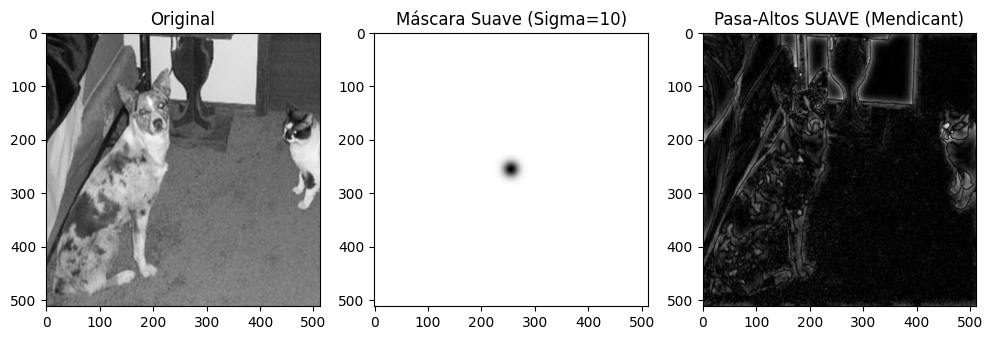

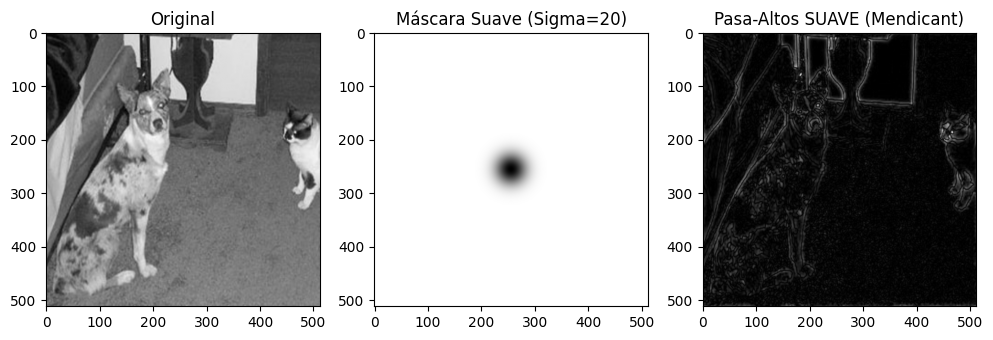

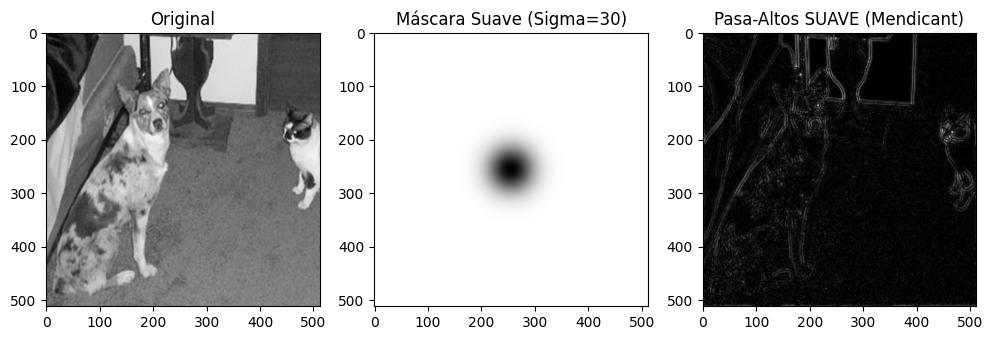

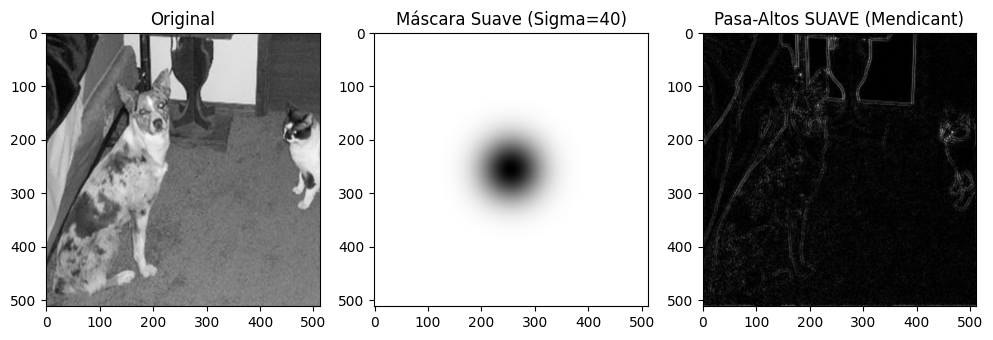

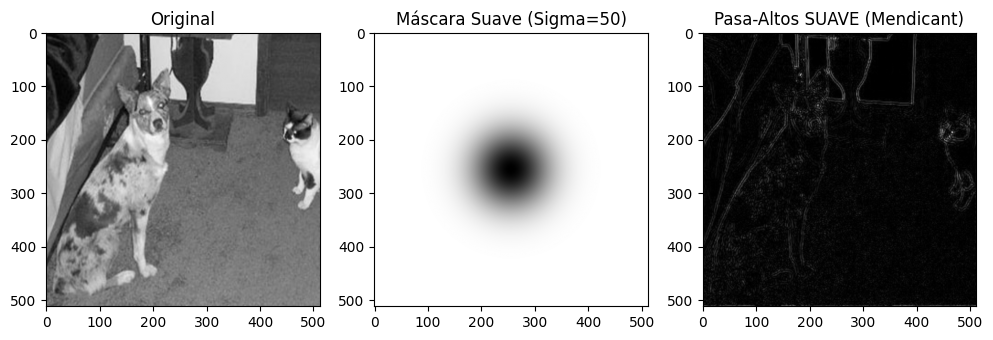

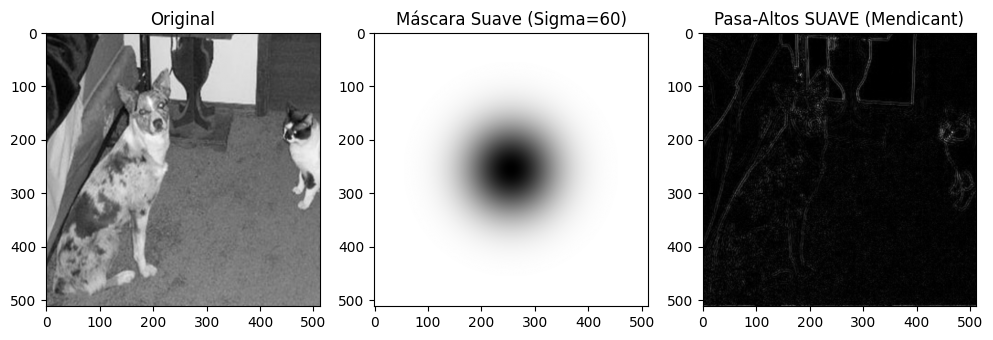

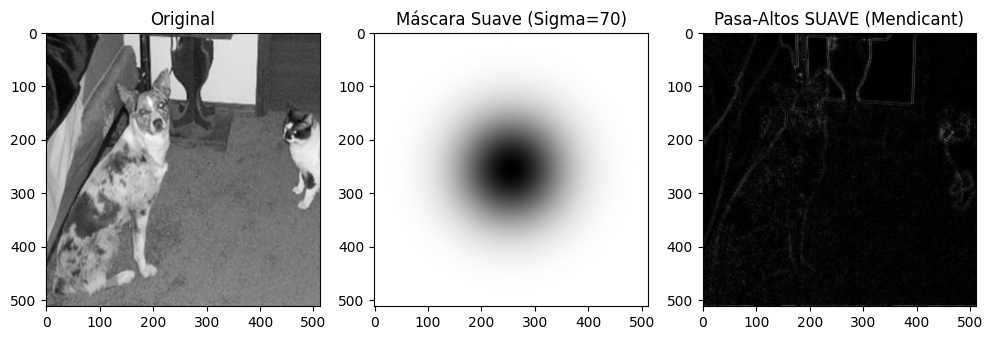

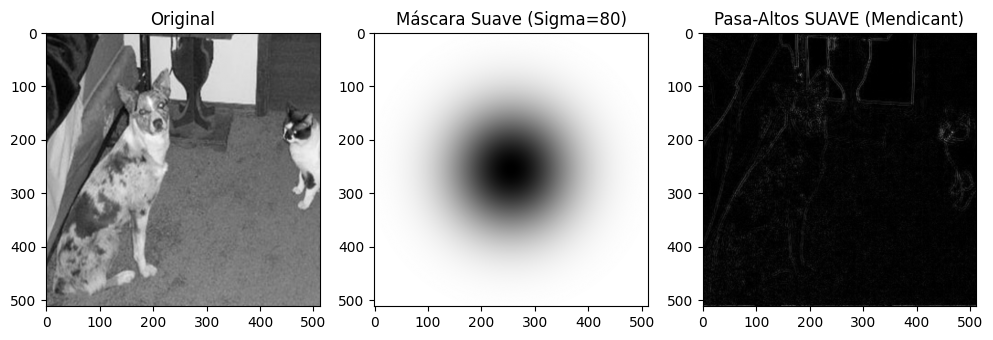

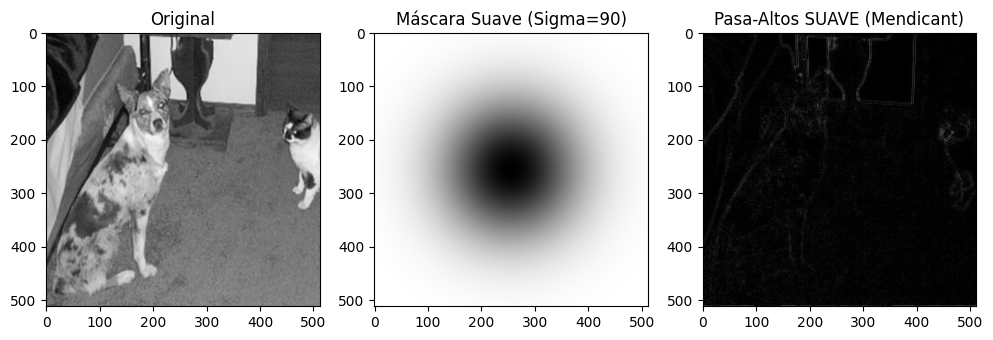

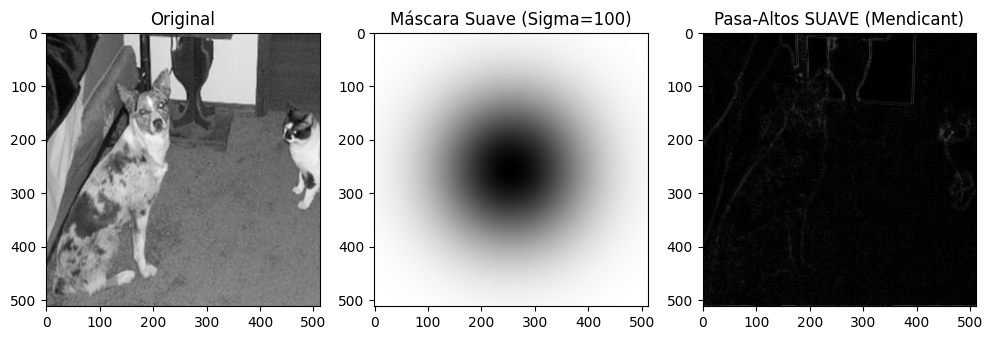

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. Cargar imagen en gris
img = cv2.imread('../../data/petimages/Dog/7.jpg', cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (512, 512)) # Redimensionar para asegurar simetría fácil

# 2. FFT
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)

# --- AQUÍ EMPIEZA LA MAGIA SUAVE ---

rows, cols = img.shape
crow, ccol = rows // 2, cols // 2

# 3. Crear una cuadrícula de coordenadas (X, Y) centrada en (0,0)
x = np.linspace(-ccol, cols - ccol, cols)
y = np.linspace(-crow, rows - crow, rows)
X, Y = np.meshgrid(x, y)

# 4. Definir SIGMA: Controla la suavidad.
# Sigma pequeño = Campana estrecha (corte más brusco)
# Sigma grande = Campana ancha (corte muy suave)
sigmas = [x for x in range(0, 100 + 1, 10)]

for sigma in sigmas:
    if sigma != 0:
        # 5. Crear la Máscara Gaussiana PASA-BAJOS (La montaña)
        # Fórmula: exp( - (distancia al centro^2) / (2 * sigma^2) )
        mask_gauss_lp = np.exp(-(X**2 + Y**2) / (2 * sigma**2))

        # 6. Crear la Máscara Gaussiana PASA-ALTOS (El cráter)
        # Simplemente invertimos la pasa-bajos: 1 - montaña
        mask_gauss_hp = 1 - mask_gauss_lp

        # --- APLICAR FILTRO ---

        # Usamos la máscara HP (Pasa-Altos) suave
        fshift_filtrado = fshift * mask_gauss_hp

        # 7. Inversa
        f_ishift = np.fft.ifftshift(fshift_filtrado)
        img_back = np.fft.ifft2(f_ishift)
        img_back = np.abs(img_back)

        # --- VISUALIZACIÓN ---
        plt.figure(figsize=(12, 6))

        plt.subplot(131)
        plt.imshow(img, cmap='gray')
        plt.title("Original")

        # Visualicemos la máscara para entender qué hicimos
        plt.subplot(132)
        plt.imshow(mask_gauss_hp, cmap='gray')
        plt.title(f"Máscara Suave (Sigma={sigma})")

        plt.subplot(133)
        plt.imshow(img_back, cmap='gray')
        plt.title("Pasa-Altos SUAVE (Mendicant)")

        plt.show()